
# การอนุมานผู้จัดการแบบกระจาย

การตั้งค่าตัวจัดการแบบกระจายสำหรับ inference แบบขนาน

inference workflow หลายตัวขนานกันอย่างน่าอายและสามารถแยกส่วนข้ามได้อย่างง่ายดาย
อุปกรณ์หลายเครื่อง
ตัวอย่างนี้สาธิตวิธีการใช้ PhysicsNeMo distribution manager เพื่อแจกจ่าย
inference ข้าม GPU หลายตัว
[ผู้จัดการแบบกระจาย](https://github.com/NVIDIA/physicsnemo/blob/main/physicsnemo/distributed/manager.py)
เป็นโปรแกรมอรรถประโยชน์ที่ให้ชุดคุณสมบัติที่มีประโยชน์ซึ่งเกี่ยวข้องกับขนาน
สิ่งแวดล้อม.

ในตัวอย่างนี้คุณจะได้เรียนรู้:

- วิธีใช้ Distributed Manager เพื่อเข้าถึงคุณสมบัติสภาพแวดล้อมแบบขนาน
- ขนาน deterministic inference ข้ามวัน-เวลาเริ่มต้นหลายรายการ
- ข้อจำกัดของ inference แบบขนานใน Earth2Studio
- กลยุทธ์หลังการประมวลผลของผลลัพธ์งานแบบขนาน


In [1]:
# /// script
# dependencies = [
#   "earth2studio[dlwp] @ git+https://github.com/NVIDIA/earth2studio.git",
#   "matplotlib",
# ]
# ///

## การเตรียมองค์ประกอบ
ตั้งค่าผู้จัดการแบบกระจายโดยการเริ่มต้น แกะกล่องมาแจกครับ
ผู้จัดการสนับสนุนสภาพแวดล้อมแบบขนาน MPI, SLURM และ PyTorch ซึ่งให้ข้อมูล
เกี่ยวกับสภาพแวดล้อมแบบขนานแต่ตัวแปรสภาพแวดล้อม

ตัวอย่างเช่น สคริปต์นี้สามารถรันได้โดยใช้:

``` ทุบตี
#โอเพนเอ็มพีไอ
mpirun -np 2 หลาม 08_distributed_manager.py
#วิ่งคบเพลิง
torchrun --standalone --nnodes=1 --nproc-per-node=2 08_distributed_manager.py
```
<div class="alert alert-danger"><h4>คำเตือน</h4><p>เมื่อทำงานแบบขนาน ตรวจสอบให้แน่ใจว่าไฟล์ .env ในตัวอย่างที่เก็บ
โฟลเดอร์ไม่มี*อยู่ ไฟล์ .env มีไว้สำหรับบิลด์เอกสารเท่านั้น</p></div>



In [2]:
import os

os.makedirs("outputs", exist_ok=True)
from dotenv import load_dotenv

load_dotenv()  # สิ่งที่ต้องทำ: สร้างฟังก์ชันการเตรียมตัวอย่างทั่วไป

import numpy as np
import torch
from loguru import logger
from physicsnemo.distributed import DistributedManager

DistributedManager.initialize()  # เรียกสิ่งนี้เพียงครั้งเดียวในสคริปต์ทั้งหมด!
dist = DistributedManager()
is_distributed = bool(getattr(dist, "_distributed", False))

if is_distributed:
    rank = dist.rank
    world_size = dist.world_size
    device = dist.device
else:
    rank = 0
    world_size = 1
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    logger.warning(
        "Torch distributed is not initialized; running this notebook in single-process mode."
    )

logger.info(f"Inference runner {rank} of {world_size} with device {device}")

/home/siamai/earth2studio-project/.venv/lib/python3.13/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/siamai/earth2studio-project/.venv/lib/python3.13/site-packages/physicsnemo/distributed/manager.py:415: UserWarning: Could not initialize using ENV, SLURM or OPENMPI methods. Assuming this is a single process job
  warn(
2026-04-25 21:05:09.579 | WARNING  | __main__:<module>:25 - Torch distributed is not initialized; running this notebook in single-process mode.
2026-04-25 21:05:09.579 | INFO     | __main__:<module>:29 - Inference runner 0 of 1 with device cuda


ถัดไปส่วนประกอบที่จำเป็นจะถูกเตรียมใช้งาน
การสนับสนุนแบบขนานที่เข้มงวดไม่ได้เป็นส่วนหนึ่งของเป้าหมายการออกแบบของ Earth2Studio แต่ก็มีอยู่บ้าง
จุดที่สภาพการแข่งขันที่อาจเกิดขึ้นได้ ดังนั้นควรได้รับการดูแลเพิ่มเติม
ดำเนินการเพื่อให้แน่ใจว่า inference แบบขนานที่ปลอดภัย



In [3]:
from earth2studio.data import WB2ERA5
from earth2studio.io import ZarrBackend
from earth2studio.models.px import DLWP

# โหลดโมเดล
package = DLWP.load_default_package()
if rank == 0:
    model = DLWP.load_model(package)

if is_distributed:
    torch.distributed.barrier()
if rank != 0:
    model = DLWP.load_model(package)

/home/siamai/earth2studio-project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead.
CuPy distance computation test failed with error: cuVS >= 24.12 or pylibraft < 24.12 should be installed to use this feature


เมื่อโหลดโมเดลที่สร้างไว้ใน Earth2Studio ไฟล์ checkpoint ของโมเดล
จะถูกดาวน์โหลดลงในแคชของเครื่อง หากแต่ละกระบวนการ inference มีสิทธิ์เข้าถึง
ตำแหน่งแคชเดียวกัน ดังนั้นควรดาวน์โหลด checkpoint ที่ถูกทริกเกอร์เพียงอันเดียว
:py:func:`load_model`.

ที่นี่ ไฟล์ :py:class:`earth2studio.models.px.DLWP` checkpoint จะถูกดาวน์โหลดครั้งแรกโดย
ประมวลผล 0 แล้วโหลดโดยกระบวนการอื่น



In [4]:
# สร้างแหล่งข้อมูล
data = WB2ERA5()

ที่เก็บข้อมูลวันที่ระยะไกลจะวางข้อมูลแคชไว้ในแคชแยกกันสำหรับแต่ละกระบวนการ
ซึ่งจะทำให้การดาวน์โหลดข้อมูลสถานะเริ่มต้นมีความปลอดภัยในระหว่าง inference แบบขนาน แต่ยังรวมถึง
หมายความว่างานหลายงานจะดาวน์โหลดวันที่-เวลาเดียวกันหากจำเป็น



In [5]:
chunks = {"time": 1, "lead_time": 1}
io = ZarrBackend(
    file_name=f"outputs/08_output_{rank}.zarr",
    chunks=chunks,
    backend_kwargs={"overwrite": True},
)

Earth2Studio ไม่ได้จัดเตรียมการสนับสนุน IO แบบกระจาย ข้อเสนอแนะคือให้เสมอ
ข้อมูลเอาต์พุตสำหรับแต่ละกระบวนการไปยังไฟล์แยกกัน จากนั้นจึงรวบรวมข้อมูลระหว่างการโพสต์
กำลังประมวลผล.

## การรัน Workflow
ต่อไปเราสามารถรัน workflow ได้ ตัวอย่างนี้จะรัน inference สำหรับวันที่สุ่ม
หลายปีและเพียงประหยัดไอน้ำทั้งคอลัมน์ แบ่งวันที่-เวลาเริ่มต้น
ในแต่ละกระบวนการ ผู้จัดการแบบกระจายจะจัดเตรียม ID อุปกรณ์สำหรับ
กระบวนการ.



In [6]:
import earth2studio.run as run

times = np.array([f"200{i:d}-06-01T00:00:00" for i in range(0, 6)])
assert (  # หมายเลข: S101
    len(times) > world_size
), "Inference runs should be greater than processes"
time_shard = np.array_split(times, world_size)[rank]

nsteps = 20
output_coords = {"variable": np.array(["tcwv"])}
io = run.deterministic(
    time_shard, nsteps, model, data, io, output_coords=output_coords, device=device
)

print(io.root.tree())
if is_distributed:
    torch.distributed.barrier()

2026-04-25 21:05:23.688 | INFO     | earth2studio.run:deterministic:78 - Running simple workflow!
2026-04-25 21:05:23.688 | INFO     | earth2studio.run:deterministic:85 - Inference device: cuda


Fetching WB2 data:   0%|          | 0/42 [00:00<?, ?it/s]

2026-04-25 21:05:23.706 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: z700 at 2002-05-31T18:00:00
2026-04-25 21:05:23.707 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: t850 at 2001-05-31T18:00:00
2026-04-25 21:05:23.708 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: t2m at 2000-05-31T18:00:00
2026-04-25 21:05:23.708 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: z500 at 2000-05-31T18:00:00
2026-04-25 21:05:23.708 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: z700 at 2001-05-31T18:00:00
2026-04-25 21:05:23.709 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: t850 at 2005-05-31T18:00:00
2026-04-25 21:05:23.709 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: z500 at 2005-05-31T18:00:00


Fetching WB2 data:   0%|          | 0/42 [00:00<?, ?it/s]

2026-04-25 21:05:23.938 | DEBUG    | earth2studio.data.utils:_make_local_details:1030 - Copying /weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr/geopotential/63427.0.0.0 to local cache
2026-04-25 21:05:23.956 | DEBUG    | earth2studio.data.utils:_make_local_details:1030 - Copying /weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr/temperature/61967.0.0.0 to local cache
2026-04-25 21:05:24.010 | DEBUG    | earth2studio.data.utils:_make_local_details:1030 - Copying /weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr/geopotential/66351.0.0.0 to local cache
2026-04-25 21:05:24.015 | DEBUG    | earth2studio.data.utils:_make_local_details:1030 - Copying /weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr/geopotential/60507.0.0.0 to local cache
2026-04-25 21:05:24.018 | DEBUG    | earth2studio.data.utils:_make_local_details:1030 - Copying /

...

2026-04-25 21:05:44.587 | DEBUG    | earth2studio.data.utils:_make_local_details:1030 - Copying /weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr/total_column_water_vapour/67812.0.0 to local cache


Fetching WB2 data: 100%|██████████| 42/42 [00:21<00:00,  1.99it/s]


2026-04-25 21:06:04.839 | SUCCESS  | earth2studio.run:deterministic:109 - Fetched data from WB2ERA5
2026-04-25 21:06:04.860 | INFO     | earth2studio.run:deterministic:139 - Inference starting!


Running inference: 100%|██████████| 21/21 [00:03<00:00,  6.03it/s]

2026-04-25 21:06:08.346 | SUCCESS  | earth2studio.run:deterministic:151 - 
Inference complete
/
├── lat (721,) float64
├── lead_time (21,) timedelta64[h]
├── lon (1440,) float64
├── tcwv (6, 21, 721, 1440) float32
└── time (6,) datetime64[ns]



## การทำ Post-Processing
ในที่สุดเราก็สามารถโพสต์ประมวลผลผลลัพธ์ได้ Xarray มีฟังก์ชันที่มีประโยชน์สำหรับ
การเปิดหลายไฟล์เป็นชุดข้อมูลเดียว :py:func:`xarray.open_mfdataset` นี้
อนุญาตให้เอาต์พุตจากกระบวนการทั้งหมดได้รับการปฏิบัติเหมือนเป็นอาร์เรย์ข้อมูลเดียว

<div class="alert alert-danger"><h4>คำเตือน</h4><p>ในกระบวนการสคริปต์นี้ 0 ใช้ในการโพสต์กระบวนการ ดังนั้นตัวอย่างจึงอยู่ในไฟล์เดียว
แนวทางปฏิบัติที่ดีที่สุดคือดำเนินการภายหลังการประมวลผลในงาน/สคริปต์ที่แยกจากกันโดยสิ้นเชิง
เพื่อใช้ทรัพยากรการประมวลผลได้ดียิ่งขึ้น</p></div>



<xarray.Dataset> Size: 523MB
Dimensions:    (time: 6, lead_time: 21, lat: 721, lon: 1440)
Coordinates:
  * time       (time) datetime64[ns] 48B 2000-06-01 2001-06-01 ... 2005-06-01
  * lead_time  (lead_time) timedelta64[h] 168B 0 days 00:00:00 ... 5 days 00:...
  * lat        (lat) float64 6kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * lon        (lon) float64 12kB 0.0 0.25 0.5 0.75 ... 359.0 359.2 359.5 359.8
Data variables:
    tcwv       (time, lead_time, lat, lon) float32 523MB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>


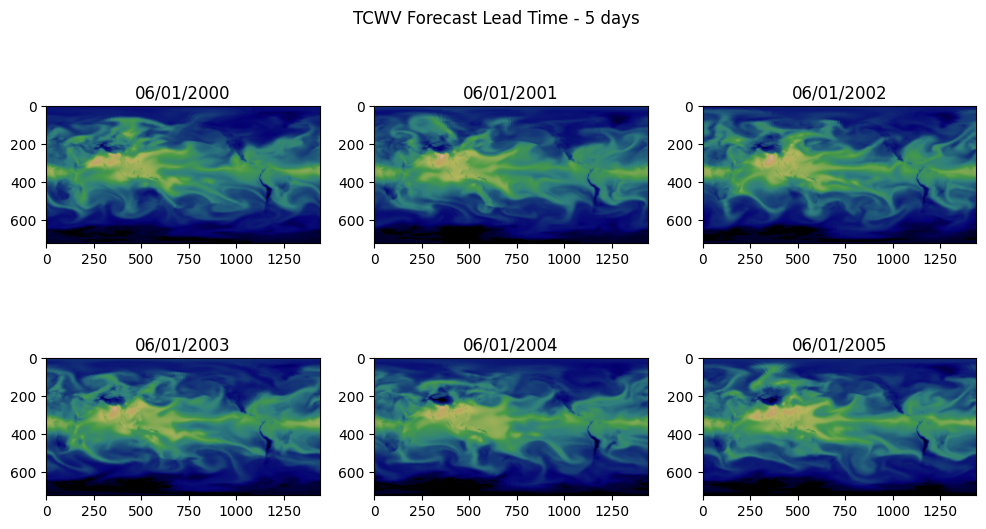

In [7]:
if rank == 0:
    import matplotlib.pyplot as plt
    import xarray as xr

    from earth2studio.utils.time import timearray_to_datetime

    paths = [f"outputs/08_output_{i}.zarr" for i in range(world_size)]
    ds = xr.open_mfdataset(paths, combine="nested", concat_dim="time", engine="zarr")
    print(ds)

    ncols = 3
    fig, ax = plt.subplots(2, ncols, figsize=(12, 6))

    time = timearray_to_datetime(ds.coords["time"].values.astype("datetime64[ns]"))
    for i in range(6):
        ax[i // ncols, i % ncols].imshow(
            ds["tcwv"].isel(time=i, lead_time=-1).values,
            cmap="gist_earth",
            vmin=0,
            vmax=100,
        )
        ax[i // ncols, i % ncols].set_title(time[i].strftime("%m/%d/%Y"))
    plt.suptitle(
        f'TCWV Forecast Lead Time - {ds.coords["lead_time"].values[-1].astype("timedelta64[ns]").astype("timedelta64[D]").astype(int)} days'
    )
    plt.savefig("outputs/08_tcwv_distributed_manager.jpg")